# Week 2 - Regresi multipel Auto MPG
Marvel Kevin Nathanael | 00000108042

Studi kasus Auto MPG dari TLM 2 / Chapter 2 Packt. Normalisasi diadaptasi dari train saja.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.keras.utils.set_random_seed(42)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
names = ["mpg", "cylinders", "displacement", "horsepower", "weight",
         "acceleration", "model_year", "origin"]
df = pd.read_csv(url, names=names, na_values="?", sep=r"\s+", engine="python",
                 usecols=range(8)).dropna()
df = pd.get_dummies(df, columns=["origin"], dtype="float32")
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
features = [c for c in df.columns if c != "mpg"]
x_train, y_train = train_df[features].astype("float32").to_numpy(), train_df["mpg"].to_numpy()
x_val, y_val = val_df[features].astype("float32").to_numpy(), val_df["mpg"].to_numpy()
x_test, y_test = test_df[features].astype("float32").to_numpy(), test_df["mpg"].to_numpy()
print("Train/val/test:", len(x_train), len(x_val), len(x_test))

Train/val/test: 250 63 79


Test MAE: 1.776 mpg
Test RMSE: 2.426 mpg


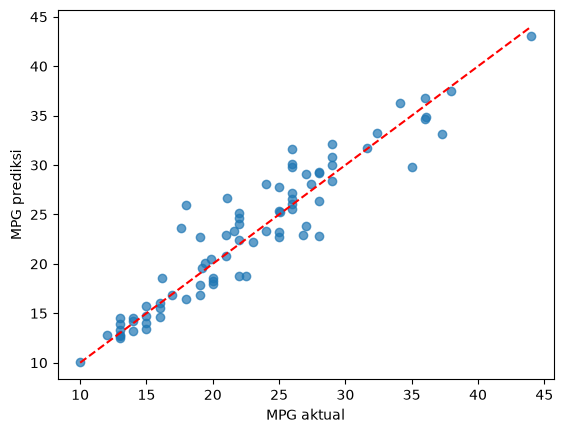

In [2]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(x_train)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)), normalizer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                    epochs=200, batch_size=32, verbose=0,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor="val_loss", patience=20, restore_best_weights=True)])
pred = model.predict(x_test, verbose=0).ravel()
print(f"Test MAE: {mean_absolute_error(y_test, pred):.3f} mpg")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f} mpg")
plt.scatter(y_test, pred, alpha=0.7)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("MPG aktual"); plt.ylabel("MPG prediksi"); plt.show()

**Catatan:** Dataset kecil dan historis. Error pada mobil modern mungkin berbeda dari data test.